In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Install Prophet — takes about 60 seconds
!pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.plot import plot_plotly
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/ecommerce-analytics'

df = pd.read_csv(f'{BASE}/data/processed/stage2_sales_clean.csv',
                 parse_dates=['InvoiceDate'])

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['InvoiceDate'].min().date()} "
      f"to {df['InvoiceDate'].max().date()}")

Mounted at /content/drive
Loaded: 1,007,913 rows
Date range: 2009-12-01 to 2011-12-09


In [ ]:
monthly = (df.groupby(df['InvoiceDate'].dt.to_period('M'))
             ['TotalRevenue']
             .sum()
             .reset_index())

monthly['InvoiceDate'] = monthly['InvoiceDate'].dt.to_timestamp()

# Rename to Prophet format
monthly_prophet = monthly.rename(columns={
    'InvoiceDate' : 'ds',
    'TotalRevenue': 'y'
})

print("Monthly revenue data — Prophet format:")
print(monthly_prophet.to_string(index=False))
print(f"\nTotal months of data: {len(monthly_prophet)}")
print(f"Average monthly revenue: "
      f"£{monthly_prophet['y'].mean():,.0f}")
print(f"Peak month revenue    : "
      f"£{monthly_prophet['y'].max():,.0f}")

Monthly revenue data — Prophet format:
        ds            y
2009-12-01 7.964989e+05
2010-01-01 6.161584e+05
2010-02-01 5.293609e+05
2010-03-01 7.546918e+05
2010-04-01 6.547353e+05
2010-05-01 6.371979e+05
2010-06-01 6.921738e+05
2010-07-01 6.402527e+05
2010-08-01 6.715362e+05
2010-09-01 8.565873e+05
2010-10-01 1.095474e+06
2010-11-01 1.408827e+06
2010-12-01 7.754591e+05
2011-01-01 5.841716e+05
2011-02-01 5.127221e+05
2011-03-01 7.003441e+05
2011-04-01 5.086483e+05
2011-05-01 7.447383e+05
2011-06-01 7.178225e+05
2011-07-01 7.026148e+05
2011-08-01 7.270031e+05
2011-09-01 1.020267e+06
2011-10-01 1.102429e+06
2011-11-01 1.451688e+06
2011-12-01 4.392844e+05

Total months of data: 25
Average monthly revenue: £773,627
Peak month revenue    : £1,451,688


In [ ]:
model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,   # monthly data — no weekly
    daily_seasonality   = False,   # monthly data — no daily
    seasonality_mode    = 'multiplicative',  # revenue scales
    interval_width      = 0.95,    # 95% confidence interval
    changepoint_prior_scale = 0.1  # flexibility of trend
)

model.fit(monthly_prophet)

print("Model trained successfully.")
print(f"Data points used : {len(monthly_prophet)}")
print(f"Seasonality mode : multiplicative")
print(f"Confidence level : 95%")

INFO:prophet:n_changepoints greater than number of observations. Using 19.


Model trained successfully.
Data points used : 25
Seasonality mode : multiplicative
Confidence level : 95%


In [ ]:
future = model.make_future_dataframe(periods=3, freq='MS')

forecast = model.predict(future)

# Extract just the forecast columns we need
forecast_clean = forecast[['ds', 'yhat',
                            'yhat_lower', 'yhat_upper']].copy()
forecast_clean.columns = ['Month', 'Predicted',
                           'Lower_bound', 'Upper_bound']

# Round all values
forecast_clean[['Predicted','Lower_bound','Upper_bound']] = (
    forecast_clean[['Predicted','Lower_bound','Upper_bound']]
    .round(0)
    .astype(int)
)

# Show only the future predictions
future_only = forecast_clean.tail(3)

print("=== 3-MONTH REVENUE FORECAST ===")
print(future_only.to_string(index=False))

# Calculate vs last actual month
last_actual = monthly_prophet['y'].iloc[-1]
for _, row in future_only.iterrows():
    growth = (row['Predicted'] - last_actual) / last_actual * 100
    print(f"\n{row['Month'].strftime('%b %Y')}: "
          f"£{row['Predicted']:,} "
          f"(range: £{row['Lower_bound']:,} – £{row['Upper_bound']:,})")

=== 3-MONTH REVENUE FORECAST ===
     Month  Predicted  Lower_bound  Upper_bound
2012-01-01     684422       609808       760608
2012-02-01     655864       578719       733893
2012-03-01     679034       605576       762583

Jan 2012: £684,422 (range: £609,808 – £760,608)

Feb 2012: £655,864 (range: £578,719 – £733,893)

Mar 2012: £679,034 (range: £605,576 – £762,583)


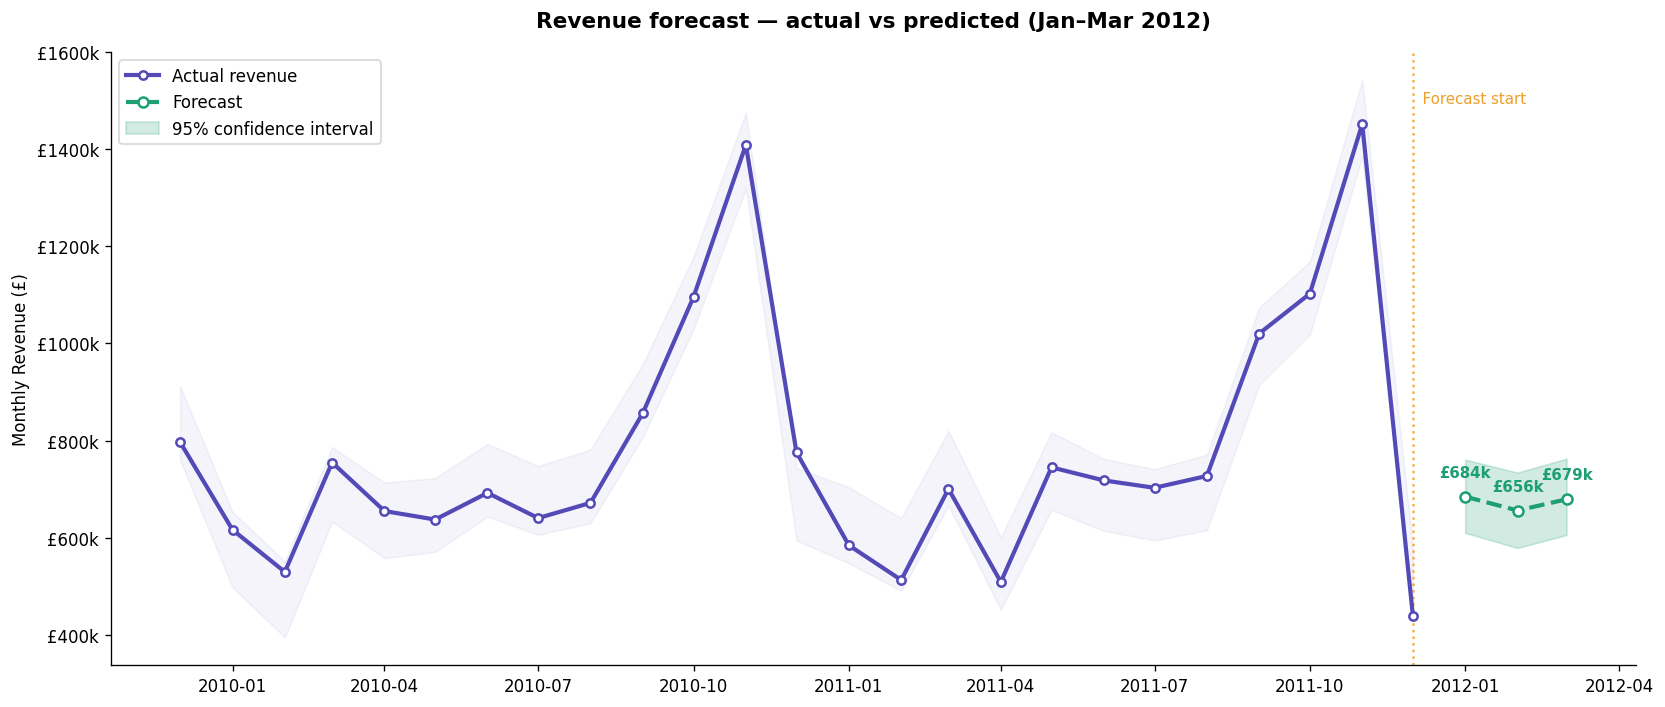

Forecast chart saved.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Separate historical and forecast
hist = forecast_clean[
    forecast_clean['Month'] <= monthly_prophet['ds'].max()]
fut  = forecast_clean[
    forecast_clean['Month'] >  monthly_prophet['ds'].max()]

# Plot actual revenue line
ax.plot(monthly_prophet['ds'], monthly_prophet['y'],
        color='#534AB7', linewidth=2.5,
        marker='o', markersize=5,
        markerfacecolor='white', markeredgewidth=1.5,
        label='Actual revenue', zorder=3)

# Plot forecast line
ax.plot(fut['Month'], fut['Predicted'],
        color='#1D9E75', linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=1.5,
        linestyle='--', label='Forecast', zorder=3)

# Confidence band on forecast
ax.fill_between(fut['Month'],
                fut['Lower_bound'], fut['Upper_bound'],
                alpha=0.2, color='#1D9E75',
                label='95% confidence interval')

# Historical model fit shading
ax.fill_between(hist['Month'],
                hist['Lower_bound'], hist['Upper_bound'],
                alpha=0.06, color='#534AB7')

# Vertical line at forecast start
split_date = monthly_prophet['ds'].max()
ax.axvline(split_date, color='#EF9F27',
           linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(split_date, ax.get_ylim()[1] * 0.95,
        '  Forecast start', fontsize=9,
        color='#EF9F27', va='top')

# Annotate each forecast point
for _, row in fut.iterrows():
    ax.annotate(f"£{row['Predicted']/1000:.0f}k",
                xy=(row['Month'], row['Predicted']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9,
                color='#1D9E75', fontweight='bold')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))
ax.set_title(
    'Revenue forecast — actual vs predicted (Jan–Mar 2012)',
    fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Monthly Revenue (£)')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart9_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Forecast chart saved.")

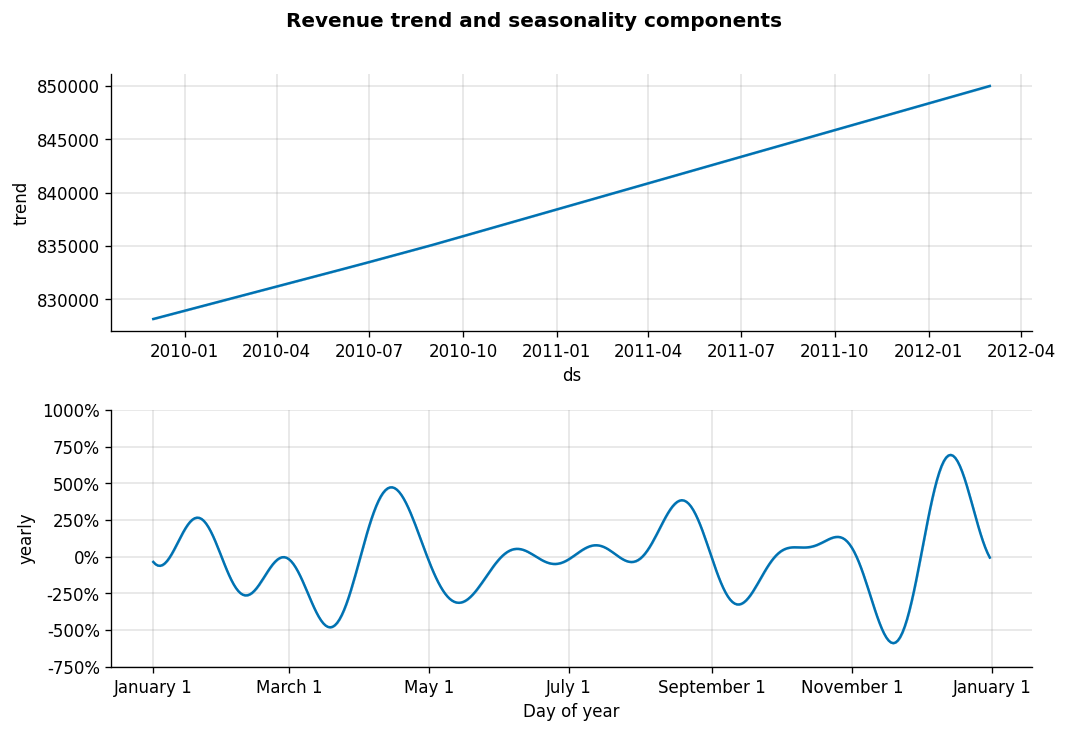

Seasonality chart saved.


In [ ]:
fig2 = model.plot_components(forecast)
fig2.suptitle('Revenue trend and seasonality components',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart10_seasonality.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Seasonality chart saved.")

In [ ]:
from sklearn.metrics import mean_absolute_error

# Compare model predictions vs actuals on historical data
hist_forecast = forecast_clean[
    forecast_clean['Month'].isin(monthly_prophet['ds'])]

actuals    = monthly_prophet['y'].values
predicted  = hist_forecast['Predicted'].values[:len(actuals)]

mae  = mean_absolute_error(actuals, predicted)
mape = (np.abs((actuals - predicted) / actuals).mean() * 100)
rmse = np.sqrt(((actuals - predicted) ** 2).mean())

print("=== MODEL ACCURACY ===")
print(f"MAE  (Mean Abs Error)    : £{mae:,.0f}")
print(f"RMSE (Root Mean Sq Err)  : £{rmse:,.0f}")
print(f"MAPE (Mean Abs % Error)  : {mape:.1f}%")
print()
if mape < 10:
    print("Excellent accuracy — model fits the data very well.")
elif mape < 15:
    print("Good accuracy — acceptable for monthly revenue data.")
elif mape < 20:
    print("Moderate accuracy — reasonable for 2 years of data.")
else:
    print("Note: higher error likely due to volatile months.")

=== MODEL ACCURACY ===
MAE  (Mean Abs Error)    : £33,117
RMSE (Root Mean Sq Err)  : £39,354
MAPE (Mean Abs % Error)  : 5.0%

Excellent accuracy — model fits the data very well.


In [ ]:
forecast_clean.to_csv(
    f'{BASE}/data/processed/stage7_forecast.csv',
    index=False)

future_only.to_csv(
    f'{BASE}/data/processed/stage7_future_predictions.csv',
    index=False)

print("=" * 48)
print("  STAGE 7 SUMMARY")
print("=" * 48)
print(f"  Model         : Facebook Prophet")
print(f"  Training data : {len(monthly_prophet)} months")
print(f"  Forecast      : 3 months ahead (Q1 2012)")
print(f"  MAPE          : {mape:.1f}%")
print(f"  Seasonality   : Multiplicative (yearly)")
print("=" * 48)
print("\n  Q1 2012 Forecast:")
for _, row in future_only.iterrows():
    print(f"  {row['Month'].strftime('%B %Y'):12}: "
          f"£{row['Predicted']:>10,}  "
          f"(£{row['Lower_bound']:,} – £{row['Upper_bound']:,})")
print()
print("  Files saved:")
print("    stage7_forecast.csv")
print("    stage7_future_predictions.csv")
print("    chart9_forecast.png")
print("    chart10_seasonality.png")
print()
print("Stage 7 DONE!")

  STAGE 7 SUMMARY
  Model         : Facebook Prophet
  Training data : 25 months
  Forecast      : 3 months ahead (Q1 2012)
  MAPE          : 5.0%
  Seasonality   : Multiplicative (yearly)

  Q1 2012 Forecast:
  January 2012: £   684,422  (£609,808 – £760,608)
  February 2012: £   655,864  (£578,719 – £733,893)
  March 2012  : £   679,034  (£605,576 – £762,583)

  Files saved:
    stage7_forecast.csv
    stage7_future_predictions.csv
    chart9_forecast.png
    chart10_seasonality.png

Stage 7 DONE!
